In [ ]:
import subprocess
import os

# Change to LLMP directory and run the command
def start_llmp():
    try:
        # Change to the LLMP directory
        llmp_path = os.path.join('..', 'LLMP')
        
        # Run the poetry command
        result = subprocess.run([
            'poetry', 'run', 'uvicorn', 'llmp.main:app', 
            '--reload', '--host', '0.0.0.0', '--port', '8000'
        ], cwd=llmp_path, check=True)
        
    except subprocess.CalledProcessError as e:
        print(f"Error running LLMP: {e}")
    except FileNotFoundError:
        print("Poetry not found. Make sure Poetry is installed and in your PATH.")

# Start LLMP server
start_llmp()

In [1]:
import sys
import os
# sys.path.append(os.path.join(os.path.dirname(__file__), '..', '..', '..')) if '__file__' in globals() else sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

print("importing kb agent")
from src.agents.kb_agent import KBAgent
print("importing adv agent")
from src.agents.adversary_agent import AdvAgent
print("importing sim agent")
from src.agents.sim_agent import SIMAgent
print("importing llmp utils")
from src.utils.llmp_utils import llmp_call
model = "gemma3n:e2b"

knowledge_bases_desc = {
    # 'physics_kb':'a knowledge base with information related to physics',
    # 'mathematics_kb':'a knowledge base with information related to mathematics',
    # 'economics_kb':'a knowledge base with information related to economics and business',
    # 'military_kb':'a knowledge base with information related to military, war and strategy',
    #'psychology_kb':'a knowledge base with information related to psychology and human behavior',
    'finance_kb': 'a knowledge base about personal finance'
              }
print("initializing kb agent")
kb_agent = KBAgent(knowledge_bases_desc,model)
print("initializing adv agent")
adv_agent = AdvAgent(knowledge_bases_desc,model,kb_agent)
print("initializing sim agent")
sim_agent = SIMAgent(model, kb_agent,adv_agent)

importing kb agent
http://192.168.1.69:8000/generate
importing adv agent
importing sim agent
importing llmp utils
initializing kb agent


h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\transformers\utils\hub.py:106: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
h:\projects\ai_based\Agent-Factory\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in H:\huggingface\models\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment va

initializing adv agent
initializing sim agent


In [3]:
sys.path

['H:\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip',
 'H:\\AppData\\Local\\Programs\\Python\\Python312\\DLLs',
 'H:\\AppData\\Local\\Programs\\Python\\Python312\\Lib',
 'H:\\AppData\\Local\\Programs\\Python\\Python312',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv',
 '',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages',
 'H:\\projects\\ai_based\\Agent-Factory\\src',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\win32',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\win32\\lib',
 'h:\\projects\\ai_based\\Agent-Factory\\.venv\\Lib\\site-packages\\Pythonwin',
 'h:\\projects\\ai_based\\Agent-Factory\\research\\notebooks\\experiments\\..\\..\\..']

In [ ]:
user_prompt = 'I am attacking your position using a pincer movement with my tank division. We are in 21st century'
iterations = 1
#comb_dialogue,diaglogue,judge_eval = sim_agent.sim_agent(user_prompt,iterations)
final_output,dialogue,judge_eval,moves = sim_agent.sim_agent(user_prompt,iterations,1,structured = True)

{'type': 'object', 'properties': {'Player': {'type': 'string'}, 'moves': {'type': 'object', 'additionalProperties': {'type': 'string'}}}, 'required': ['Player', 'moves']}

Turn 0
KB Agent
http://192.168.1.69:8000/generate
finance_kb
RAG pipeline
intfloat/e5-large-v2
Retrieving embeddings...
finance_kb
RAG pipeline
intfloat/e5-large-v2
Retrieving embeddings...
Performing semantic search...
Performing semantic search...
Unloading embeddings model...
Processing context...
Unloading embeddings model...
Processing context...
Processing references...
Calling LLMP...
http://192.168.1.69:8000/generate
Processing references...
Calling LLMP...
http://192.168.1.69:8000/generate
move_adv_1_0 play
judge
http://192.168.1.69:8000/generate
move_adv_1_0 play
judge
http://192.168.1.69:8000/generate


In [4]:
dialogue

['Player 2 did: I am attacking your position using a pincer movement with my tank division. We are in 21st century',
 'Player 1 did: {\n"Player": "Rich Dad",\n"moves": {\n"Counter": "I am not engaging in a military conflict. My financial strategy is focused on building wealth through real estate and small-cap stocks, not through direct confrontation or military action. The player\'s statement is a metaphorical attack on my financial position, framed as a military maneuver. I will respond by highlighting the inherent instability and potential for loss associated with military endeavors, contrasting it with the long-term, passive wealth-building of my chosen financial paths. I will also emphasize the importance of financial intelligence and the dangers of clinging to outdated, fear-based approaches to money."\n}\n}\n']

In [2]:
# GRAND SIM


num_sims = 1
iterations = 3
rand_event_chance = 0.7
user_prompt = 'I am attacking your position using a pincer movement with my tank division. We are in 21st century'
user_prompt = 'Um cliente de psicologia tem os seguintes sintomas: Ataques de ansiedade, Desatento, Impulsividade sexual, Humor depressivo , Movimentos motores repetitivos. Eu (jogador 1) acredito ser Défice de atenção e hiperatividade (impulsividade), tu (jogador 2) debates comigo.'
user_prompt = " I am thinking of getting a 1.5k guitar amplifier."

final_outputs = []
dialogues = []
judge_evals = []
moves_list = []
for sim in range(num_sims):
    print(f"\n\n\n\n\n\n\n**SIMULATION {sim}**\n\n\n")
    final_output,dialogue,judge_eval,moves = sim_agent.sim_agent(user_prompt,iterations,rand_event_chance,structured = True)
    final_outputs.append(final_output)
    dialogues.append(dialogue)
    judge_evals.append(judge_eval)
    moves_list.append(moves)

    








**SIMULATION 0**



{'type': 'object', 'properties': {'Player': {'type': 'string'}, 'moves': {'type': 'object', 'additionalProperties': {'type': 'string'}}}, 'required': ['Player', 'moves']}

Turn 0
KB Agent
http://192.168.1.69:8000/generate
finance_kb
RAG pipeline
intfloat/e5-large-v2
Retrieving embeddings...
Performing semantic search...
Unloading embeddings model...
Processing context...
Processing references...
Calling LLMP...
http://192.168.1.69:8000/generate


In [3]:
import json
from itertools import zip_longest
import pandas as pd

def preprocess_sim(sim_dialogue,sim_judge_eval):
    
    formated_dialogue = [sim_dialogue[0].replace('Player 2 did:','Opening Move:')]
    for response in sim_dialogue[1:]:
        response = response.strip('Player 2 did:')
        response = response.strip('Player 1 did:')
        response = response.strip('\n**Random event**:')
        data = json.loads(response)
        formated_dialogue.append(data)
    formated_judge_eval = json.loads(sim_judge_eval)
    return formated_dialogue, formated_judge_eval
#formated_dialogue, formated_judge_eval = process_sim(dialogues[2],judge_evals[2])


def post_process_sim(sim_dialogues,sim_judge_evals):
    """Post process the simulation's data.
    Format the dialogue and judge evaluations.

    Args:
        sim_dialogues (_type_): list of dialogues from all simulations (branch)
        sim_judge_evals (_type_): list of judge evals from each simulation (branch judge)
    """
    
    formated_dialogues = []
    formated_judge_evals = []
    failed_sims = []
    for i in range(len(sim_dialogues)):
        try:
            formated_dialogue, formated_judge_eval = preprocess_sim(sim_dialogues[i],sim_judge_evals[i])
            formated_dialogues.append(formated_dialogue)
            formated_judge_evals.append(formated_judge_eval)
        except:
            failed_sims.append(i)
    return formated_dialogues, formated_judge_evals, failed_sims
    

def transform_moves(moves_dict):
    """Transforms moves dictionary to a more structured format.

    Args:
        moves_dict (list): list of moves dictionaries

    Returns:
        _type_: formated moves dictionary
    """
    new_moves = {}
    for _, value in moves_dict["moves"].items():
        if isinstance(value, str) and ":" in value:
            move_name, description = map(str.strip, value.split(":", 1))
            new_moves[move_name] = description
        else:
            new_moves[value] = ""  # fallback if not formatted as expected

    return {
        "Player": moves_dict["Player"],
        "moves": new_moves
    }
    

def transform_moves_list(moves_list):
    """Transforms a list of moves dictionaries to a more structured format.

    Args:
        moves_list (list): list of moves dictionaries

    Returns:
        _type_: formated list of moves dictionaries
    """
    new_moves_list = []
    for moves_dict in moves_list:
        if "Opening Move" in moves_dict:
            new_moves_list.append(moves_dict)
        elif "Random Event" in moves_dict.keys():
            new_moves_list.append(moves_dict)
        else:
            transformed_move = transform_moves(moves_dict)
            new_moves_list.append(transformed_move)
    return new_moves_list

def transform_sims_moves(sims_moves):
    """transform all sims moves to a more structured format

    Args:
        sims_moves (list): list of all simulations moves

    Returns:
        _type_: structured list of all simulations moves
    """
    new_sims_moves = []
    for i in range(len(sims_moves)):
        new_sim_moves = transform_moves_list(sims_moves[i])
        new_sims_moves.append(new_sim_moves)
        
    return new_sims_moves

def get_opening_move(sim_dialogue):
    """Extract opening move from the formatted simulation.

    Args:
        formatted_sim (list): list of events
    """
    opening_move = sim_dialogue[0]
    event_list = sim_dialogue[1:]
    
    return opening_move, event_list

def fill_na_rand_events(event_list):
    """Generate empty random events

    Args:
        event_list (list): list of events

    Returns:
        list: list of events with empty random events
    """
    new_event_list = []
        
    for i, play in enumerate(event_list):
        if "Player" in play and play["Player"] == "Player 2":
            if not (new_event_list and "Random Event" in new_event_list[-1]):
                # Insert dummy event before Player 2's move
                new_event_list.append({
                    "Random Event": "N/A",
                    "EFFECT ON PLAYER 1": "N/A",
                    "EFFECT ON PLAYER 2": "N/A"
                })
        new_event_list.append(play)
        
    return new_event_list

def get_random_events(event_list):
    """Extract random events from the event list.

    Args:
        event_list (list): list of events

    Returns:
        list: list of random events
    """
    rand_events = []
    play_list = []
    for event in event_list:
        if "Random Event" in event.keys():
            rand_events.append(event)
        elif "Player" in event.keys():
            play_list.append(event)
            
            
            
    return rand_events,play_list

def apply_turns_re(rand_events):
    """Apply turns to the random events.

    Args:
        rand_events (list): list of random events

    Returns:
        list: list of random events with turns
    """
    turned_ra_events = rand_events.copy()
    for i, ra_event in enumerate(turned_ra_events):
        ra_event['turn'] = i+1
            
    return turned_ra_events

def clean_rand_events_list(rand_events):
    """Remove NA random events

    Args:
        rand_events (list): list of turned random events
    """
    
    for rand_event in rand_events:
        if "N/A" in rand_event.values():
            rand_events.remove(rand_event)
    return rand_events

def apply_turns_plays(move_list):
    """Apply turns to the plays.

    Args:
        play_list (list): list of plays

    Returns:
        list: list of plays with turns
    """
    p1_moves = [move for move in move_list if "moves" in move.keys() and move['Player'] == 'Player 1']
    p2_moves = [move for move in move_list if "moves" in move.keys() and move['Player'] == 'Player 2']
    for p1_move in p1_moves:
        p1_move['turn'] = p1_moves.index(p1_move)
    for p2_move in p2_moves:
        p2_move['turn'] = p2_moves.index(p2_move) + 1
    turned_moves = [move for pair in zip_longest(p1_moves, p2_moves) for move in pair if move is not None]
    

    return turned_moves

def get_move_df(turned_move_dict):
    """Get a dataframe from the moves dictionary.

    Args:
        move_dict (dict): moves dictionary

    Returns:
        _type_: dataframe of moves
    """
    df = pd.DataFrame([{
        'Player': turned_move_dict['Player'],
        'move': move,
        'move_desc': desc,
        'turn': turned_move_dict['turn']
    } for move, desc in turned_move_dict['moves'].items()])
    
    return df

def convert_moves_to_df(turned_moves_list):
    """Get a dataframe from the moves list.

    Args:
        moves_list (list): list of moves

    Returns:
        _type_: dataframe of moves
    """
    df = pd.DataFrame()
    for move_dict in turned_moves_list:
        temp_df = get_move_df(move_dict)
        df = pd.concat([df, temp_df], ignore_index=True)
    
    return df

def get_rand_events_df(turned_rand_events_list):
    """Get a dataframe from the random events list.

    Args:
        rand_events_list (list): list of random events

    Returns:
        _type_: dataframe of random events
    """
    df = pd.DataFrame(turned_rand_events_list)
    return df

def combine_dfs(moves_df, rand_event_df,opening_move):
    """Combine the moves dataframe and random events dataframe.

    Args:
        moves_df (_type_): moves dataframe
        rand_event_df (_type_): random events dataframe

    Returns:
        _type_: combined dataframe
    """
    sim_df = pd.DataFrame()
    if rand_event_df is None:
        sim_df = moves_df.copy()
        sim_df['Random Event'] = ''
        sim_df['Effect on Player 1'] = ''
        sim_df['Effect on Player 2'] = ''
    else:
        sim_df = moves_df.merge(rand_event_df, on='turn', how='left')
    sim_df['opening_move'] = opening_move
    
    columns = ['opening_move','turn', 'Player', 'move', 'move_desc', 'Random Event', 'Effect on Player 1', 'Effect on Player 2']
    sim_df = sim_df[columns]
    
    return sim_df
    
def process_sim(formated_sim_dialogue):
    """Simulation processing into dataframe pipeline

    Args:
        formated_sim_dialogue (list): formated simulation dialogue
    """
    opening_move, event_list = get_opening_move(formated_sim_dialogue)
    event_list = fill_na_rand_events(event_list)
    rand_events,move_list = get_random_events(event_list)
    turned_rand_events = apply_turns_re(rand_events)
    turned_rand_events = clean_rand_events_list(turned_rand_events)
    turned_moves = apply_turns_plays(move_list)
    moves_df = convert_moves_to_df(turned_moves)
    rand_events_df = get_rand_events_df(turned_rand_events)
    sim_df = combine_dfs(moves_df, rand_events_df,opening_move)
    
    return sim_df
    
def process_grand_sim(formated_sims_dialogues):
    """Combines all simulations into grand sim

    Args:
        formated_sims_dialogues (list): list of simulation events
    """
    grand_sim_df = pd.DataFrame()
    for sim in formated_sims_dialogues:
        index = formated_sims_dialogues.index(sim)
        sim_df = process_sim(sim)
        sim_df['sim'] = index
        grand_sim_df = pd.concat([grand_sim_df, sim_df], ignore_index=True)
        
    columns = ['opening_move','sim','turn','Player','move','move_desc','Random Event','Effect on Player 1','Effect on Player 2']
    grand_sim_df = grand_sim_df[columns]
        
    return grand_sim_df


def process_judge_df(judge_eval):

    player_summary = {
        "player_1_weaknesses": judge_eval["Player 1 Status"]["Weaknesses"],
        "player_1_strengths": judge_eval["Player 1 Status"]["Strengths"],
        "player_1_overall_status": judge_eval["Player 1 Status"]["Overall Status"],
        "player_2_weaknesses": judge_eval["Player 2 Status"]["Weaknesses"],
        "player_2_strengths": judge_eval["Player 2 Status"]["Strengths"],
        "player_2_overall_status": judge_eval["Player 2 Status"]["Overall Status"],
        "outcome": judge_eval["Outcome"],
        "advantage": judge_eval["Advantage"],
    }

    # Convert to DataFrame
    df_summary = pd.DataFrame([player_summary])
    return df_summary

def process_judge_evals(formated_judge_evals):
    """Process the judge evaluations data.

    Args:
        formated_judge_evals (_type_): _description_

    Returns:
        _type_: _description_
    """

    grand_judge_df = pd.DataFrame()
    for judge in formated_judge_evals:
        index = formated_judge_evals.index(judge)
        judge_df = process_judge_df(judge)
        judge_df['sim'] = index
        grand_judge_df = pd.concat([grand_judge_df, judge_df], ignore_index=True)
    return grand_judge_df

In [4]:
dialogues

[['Player 2 did: Um cliente de psicologia tem os seguintes sintomas: Ataques de ansiedade, Desatento, Impulsividade sexual, Humor depressivo , Movimentos motores repetitivos. Eu (jogador 1) acredito ser Défice de atenção e hiperatividade (impulsividade), tu (jogador 2) debates comigo.',
  'Player 1 did: {\n"Player": "Player 1",\n"moves": {\n"Move: Presenting Symptoms - Direct and Comprehensive": "The client presents with a constellation of symptoms including anxiety attacks, inattention, impulsive sexual behavior, depressive humor, and repetitive motor movements. These are key indicators of a potential ADHD diagnosis.",\n"Move: ADHD Diagnostic Criteria - Explicitly State Criteria": "The Diagnostic Criteria for ADHD include inattention, hyperactivity, and impulsivity. The client\'s symptoms align strongly with these core features. The presence of repetitive motor movements further supports this diagnosis.",\n"Move: Differential Diagnosis - Address Potential Alternatives": "While other c

In [6]:
def process_sim(formated_sim_dialogue):
    """Simulation processing into dataframe pipeline
   
    Args:
        formated_sim_dialogue (list): formated simulation dialogue
    """
    opening_move, event_list = get_opening_move(formated_sim_dialogue)
    event_list = fill_na_rand_events(event_list)
    rand_events,move_list = get_random_events(event_list)
    turned_rand_events = apply_turns_re(rand_events)
    turned_rand_events = clean_rand_events_list(turned_rand_events)
    turned_moves = apply_turns_plays(move_list)
    moves_df = convert_moves_to_df(turned_moves)
    rand_events_df = get_rand_events_df(turned_rand_events)
    #sim_df = combine_dfs(moves_df, rand_events_df,opening_move)
    
    return turned_rand_events

moves_df = process_sim(new_formated_dialogues[0])

In [5]:
moves_df

NameError: name 'moves_df' is not defined

In [6]:
formated_dialogues, formated_judge_evals, failed_sims = post_process_sim(dialogues,judge_evals)
new_formated_dialogues = transform_sims_moves(formated_dialogues)

grand_sim_df = process_grand_sim(new_formated_dialogues)
grand_sim_judges_df = process_judge_evals(formated_judge_evals)

In [6]:
new_formated_dialogues

[['Opening Move: Um cliente de psicologia tem os seguintes sintomas: Ataques de ansiedade, Desatento, Impulsividade sexual, Humor depressivo , Movimentos motores repetitivos. Eu (jogador 1) acredito ser Défice de atenção e hiperatividade (impulsividade), tu (jogador 2) debates comigo.',
  {'Player': 'Dr. Aris Thorne',
   'moves': {'Differential Diagnosis – Anxiety Spectrum”, “Description”': '“Given the client’s reported anxiety alongside other symptoms, I’ll initiate a thorough assessment to rule out Generalized Anxiety Disorder, Panic Disorder, or Social Anxiety Disorder. These conditions frequently present with similar symptom clusters, particularly anxiety alongside attentional difficulties and impulsivity.”, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90, 1.95, 2.00, 2.05, 2.10, 2.15, 2.20, 2.25, 2.30, 2.35, 2.40, 2.

In [7]:
grand_sim_df

,opening_move,sim,turn,Player,move,move_desc,Random Event,Effect on Player 1,Effect on Player 2
0,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,The client presents with a constellation of sy...,,NaN,NaN,NaN
1,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,The Diagnostic Criteria for ADHD include inatt...,,NaN,NaN,NaN
2,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,"While other conditions like anxiety disorders,...",,NaN,NaN,NaN
3,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,The client's impulsive sexual behavior and pot...,,NaN,NaN,NaN
4,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,The client's reported inattention is a key sym...,,NaN,NaN,NaN
5,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,Depressive humor can be a co-occurring conditi...,,NaN,NaN,NaN
6,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,"Repetitive motor movements (e.g., fidgeting, r...",,NaN,NaN,NaN
7,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,"In summary, the client's symptoms – anxiety at...",,NaN,NaN,NaN
8,Opening Move: Um cliente de psicologia tem os ...,0,0,Player 1,"Further assessment, including a detailed histo...",,NaN,NaN,NaN
9,Opening Move: Um cliente de psicologia tem os ...,0,1,Player 2,While the client presents with several symptom...,,NaN,NaN,NaN


In [8]:
grand_sim_df.to_csv('grand_sim_3.csv', index=False)
grand_sim_judges_df.to_csv('grand_sim_judges_3.csv', index=False)

In [6]:
import pandas as pd

grand_sim_df = pd.read_csv('grand_sim_2.csv')
grand_sim_judges_df = pd.read_csv('grand_sim_judges_2.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'grand_sim_2.csv'

In [7]:
grand_sim_df.loc[grand_sim_df['moves_desc']=='']

,opening_move,Player,moves,moves_desc,turn,Random Event,player_effect,sim


In [78]:
grand_sim_df

,opening_move,Player,moves,moves_desc,turn,Random Event,player_effect,sim
0,I am attacking your position using a pincer mo...,Player 1,Counter-Attack,"Immediate offensive push towards the center, a...",0,NaN,NaN,0
1,I am attacking your position using a pincer mo...,Player 1,Mobile Reserve Deployment,Rapid repositioning of a mechanized infantry b...,0,NaN,NaN,0
2,I am attacking your position using a pincer mo...,Player 1,Electronic Warfare,Initiate jamming of enemy communications and t...,0,NaN,NaN,0
3,I am attacking your position using a pincer mo...,Player 1,Artillery Barrage,Concentrated artillery fire on the tank divisi...,0,NaN,NaN,0
4,I am attacking your position using a pincer mo...,Player 1,Defensive Consolidation,Strengthen defensive lines with additional inf...,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...
95,I am attacking your position using a pincer mo...,Player 1,Immediate Defensive Consolidation,Reinforce the most vulnerable sector with addi...,2,NaN,NaN,3
96,I am attacking your position using a pincer mo...,Player 1,Mobile Reserve Deployment,Rapidly reposition the reinforced reserve forc...,2,NaN,NaN,3
97,I am attacking your position using a pincer mo...,Player 1,Electronic Countermeasures – Focused Jamming,"Intensify electronic warfare efforts, specific...",2,NaN,NaN,3
98,I am attacking your position using a pincer mo...,Player 1,Artillery Concentration – Deep Strike,Shift artillery fire to target the advancing t...,2,NaN,NaN,3


In [2]:
def get_nodes(grand_sim_df,sim):
    """Get the nodes for the given turn and simulation.

    Args:
        grand_sim_df (DataFrame): grand simulation dataframe
        turn (int): turn number
        sim (int): simulation number

    Returns:
        _type_: _description_
    """
    df_0 = grand_sim_df[(grand_sim_df['sim'] == sim)]
    
    params = ['Player','moves','turn','sim']
    moves = df_0[params].iloc[1:].to_dict(orient = 'records')
    for move in moves:
        move['title'] = f"{move['Player']} - {move['moves']}"
    
    return moves

In [3]:
opening_move = grand_sim_df.iloc[0]['opening_move']

moves = get_nodes(grand_sim_df,0)

In [4]:
moves

[{'Player': 'Player 1',
  'moves': 'Mobile Reserve Deployment',
  'turn': 0,
  'sim': 0,
  'title': 'Player 1 - Mobile Reserve Deployment'},
 {'Player': 'Player 1',
  'moves': 'Electronic Warfare',
  'turn': 0,
  'sim': 0,
  'title': 'Player 1 - Electronic Warfare'},
 {'Player': 'Player 1',
  'moves': 'Artillery Barrage',
  'turn': 0,
  'sim': 0,
  'title': 'Player 1 - Artillery Barrage'},
 {'Player': 'Player 1',
  'moves': 'Defensive Consolidation',
  'turn': 0,
  'sim': 0,
  'title': 'Player 1 - Defensive Consolidation'},
 {'Player': 'Player 2',
  'moves': 'Immediate Tactical Withdrawal',
  'turn': 1,
  'sim': 0,
  'title': 'Player 2 - Immediate Tactical Withdrawal'},
 {'Player': 'Player 2',
  'moves': 'Counter-Artillery Fire',
  'turn': 1,
  'sim': 0,
  'title': 'Player 2 - Counter-Artillery Fire'},
 {'Player': 'Player 2',
  'moves': 'Electronic Countermeasures',
  'turn': 1,
  'sim': 0,
  'title': 'Player 2 - Electronic Countermeasures'},
 {'Player': 'Player 2',
  'moves': 'Combine

In [222]:
opening_move

'I am attacking your position using a pincer movement with my tank division. We are in 21st century'

In [5]:
opening_move_node = {'Player':'opening_move',
                     'moves':'opening_move',
                     'turn':0,
                     'sim':0,
                     'title':f"opening_move - {opening_move}",
                     }

C:\Users\w10\AppData\Local\Temp\ipykernel_18108\3709393655.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


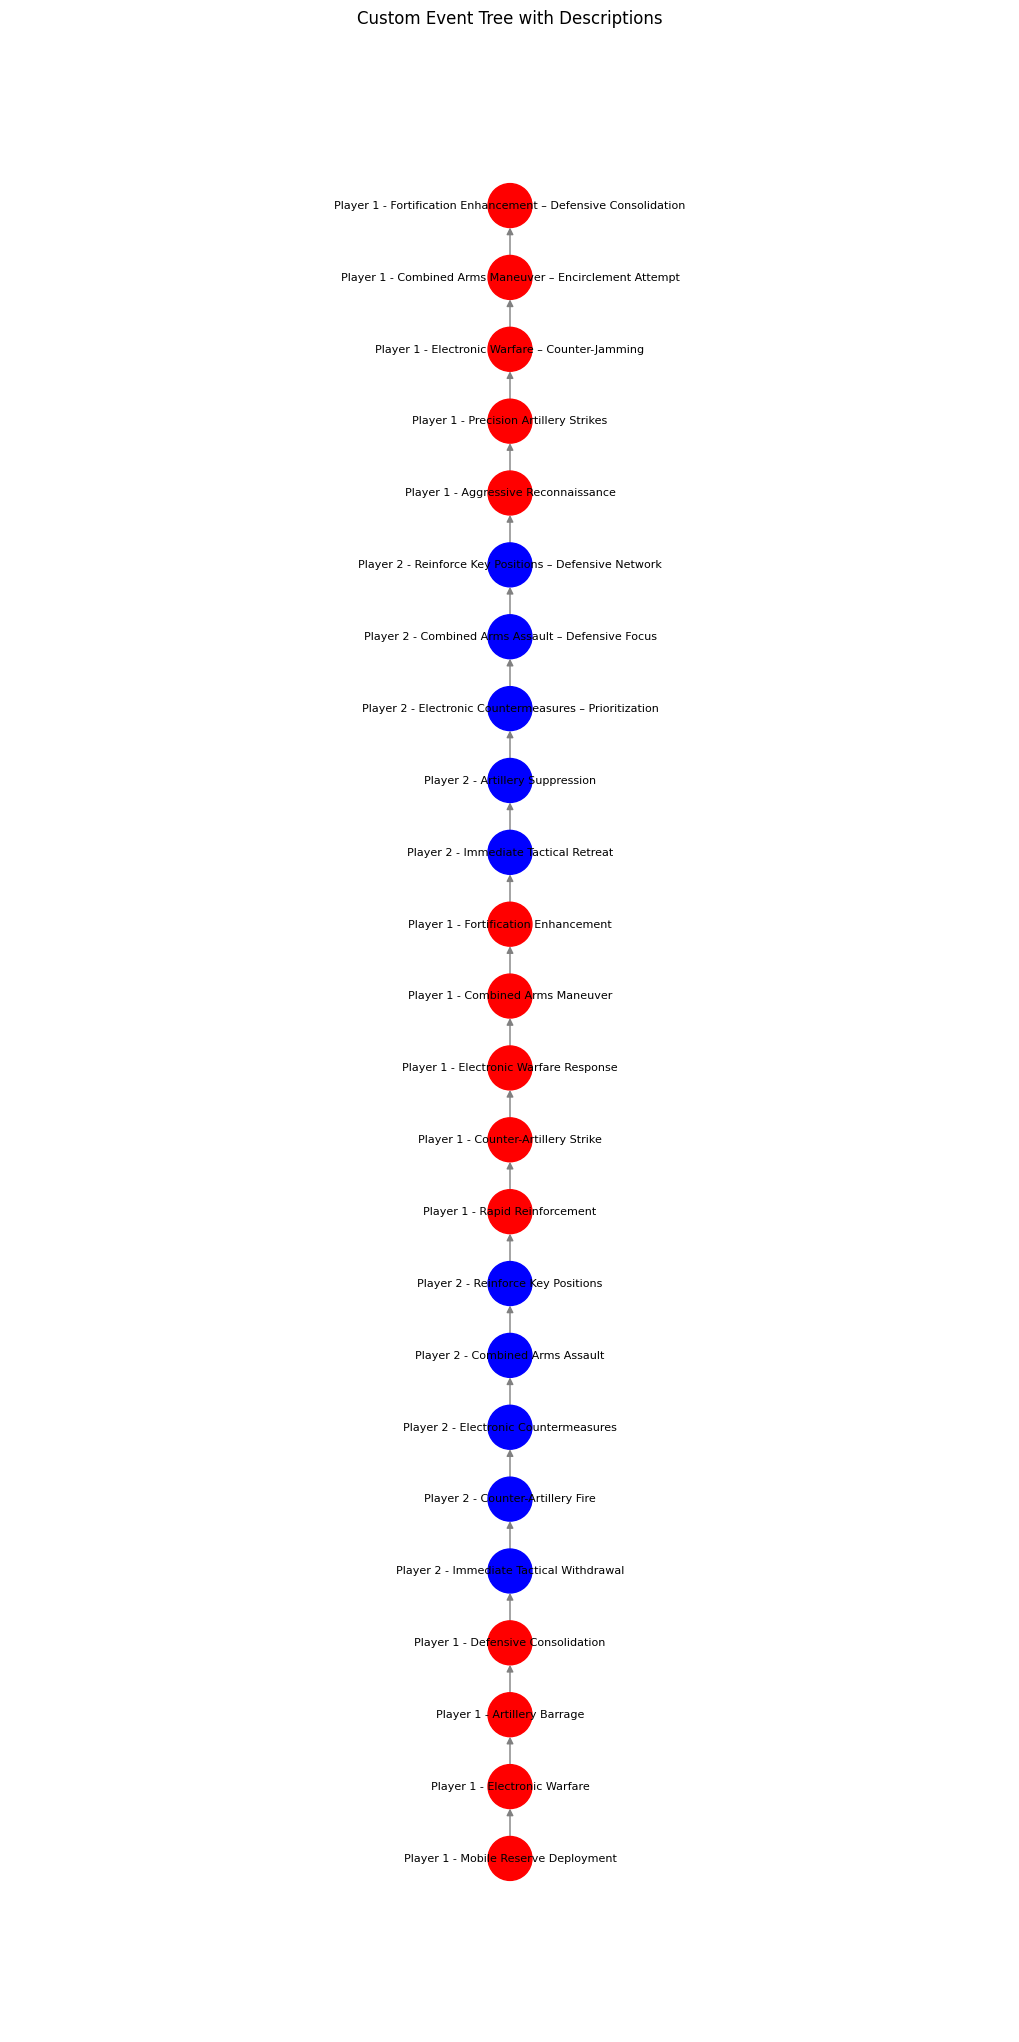

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()


# Global definitions
color_map = {
    "Player 1": "red",
    "Player 2": "blue",
    }

# Insert opening move as node 0
#nodes = [opening_move_node] + moves
nodes = moves
node_labels = {}
#G.add_node(opening_move_node['title'])
node_colors = ["green"]
node_colors = []


# Node definition
for node in nodes:
    node['title'] = f"{node['Player']} - {node['moves']}"
    title = node["title"]
    node_labels[title] = 'description'
    node_colors.append(color_map.get(node['Player'], "gray"))
    G.add_node(title)

# Edges definition
for i in range(len(nodes) - 1):
    source = nodes[i]['title']
    target = nodes[i+1]['title']
    G.add_edge(source, target)

# Positioning
#pos = {opening_move_node['title']:(0.0)} #opening move position SHOULD BE SEPARATE FROM SIMS
pos = {}
for i in range(len(nodes)):
    coordinates = (0,i)
    title = nodes[i]['title']
    pos[title] = coordinates
    

# Plotting
plt.figure(figsize=(10, 20))
nx.draw(
    G,
    pos,
    #labels=node_labels,
    with_labels=True,
    arrows=True,
    node_color=node_colors,
    node_size=1000,
    font_size=8,
    edge_color='gray'
)
plt.title("Custom Event Tree with Descriptions")
plt.axis('off')
plt.tight_layout()
plt.show()


# FIGURE OUT A WAY OF SEPARATING OPENING MOVE NODE FROM SIMULATION NODES

In [9]:
G.nodes['Player 1 - Mobile Reserve Deployment']

{}

In [165]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()


# Global definitions
color_map = {
    "Player 1": "red",
    "Player 2": "blue",
    }

# Insert opening move as node 0
#nodes = [opening_move_node] + moves
nodes = moves
node_labels = {}
#G.add_node(opening_move_node['title'])
node_colors = ["green"]
node_colors = []


# Node definition
for node in nodes:
    node['title'] = f"{node['Player']} - {node['moves']}"
    title = node["title"]
    node_labels[title] = 'description'
    node_colors.append(color_map.get(node['Player'], "gray"))
    G.add_node(title)

# Edges definition
for i in range(len(nodes) - 1):
    source = nodes[i]['title']
    target = nodes[i+1]['title']
    G.add_edge(source, target)

# Positioning
#pos = {opening_move_node['title']:(0.0)} #opening move position SHOULD BE SEPARATE FROM SIMS
pos = {}
for i in range(len(nodes)):
    coordinates = (0,i)
    title = nodes[i]['title']
    pos[title] = coordinates
    

# Plotting
plt.figure(figsize=(10, 20))
nx.draw(
    G,
    pos,
    #labels=node_labels,
    with_labels=True,
    arrows=True,
    node_color=node_colors,
    node_size=1000,
    font_size=8,
    edge_color='gray'
)
plt.title("Custom Event Tree with Descriptions")
plt.axis('off')
plt.tight_layout()
plt.show()


# FIGURE OUT A WAY OF SEPARATING OPENING MOVE NODE FROM SIMULATION NODES

{'Player 1 - Mobile Reserve Deployment': (0, 0),
 'Player 1 - Electronic Warfare': (0, 1),
 'Player 1 - Artillery Barrage': (0, 2),
 'Player 1 - Defensive Consolidation': (0, 3),
 'Player 2 - Immediate Tactical Withdrawal': (0, 4),
 'Player 2 - Counter-Artillery Fire': (0, 5),
 'Player 2 - Electronic Countermeasures': (0, 6),
 'Player 2 - Combined Arms Assault': (0, 7),
 'Player 2 - Reinforce Key Positions': (0, 8),
 'Player 1 - Rapid Reinforcement': (0, 9),
 'Player 1 - Counter-Artillery Strike': (0, 10),
 'Player 1 - Electronic Warfare Response': (0, 11),
 'Player 1 - Combined Arms Maneuver': (0, 12),
 'Player 1 - Fortification Enhancement': (0, 13),
 'Player 2 - Immediate Tactical Retreat': (0, 14),
 'Player 2 - Artillery Suppression': (0, 15),
 'Player 2 - Electronic Countermeasures – Prioritization': (0, 16),
 'Player 2 - Combined Arms Assault – Defensive Focus': (0, 17),
 'Player 2 - Reinforce Key Positions – Defensive Network': (0, 18),
 'Player 1 - Aggressive Reconnaissance': (

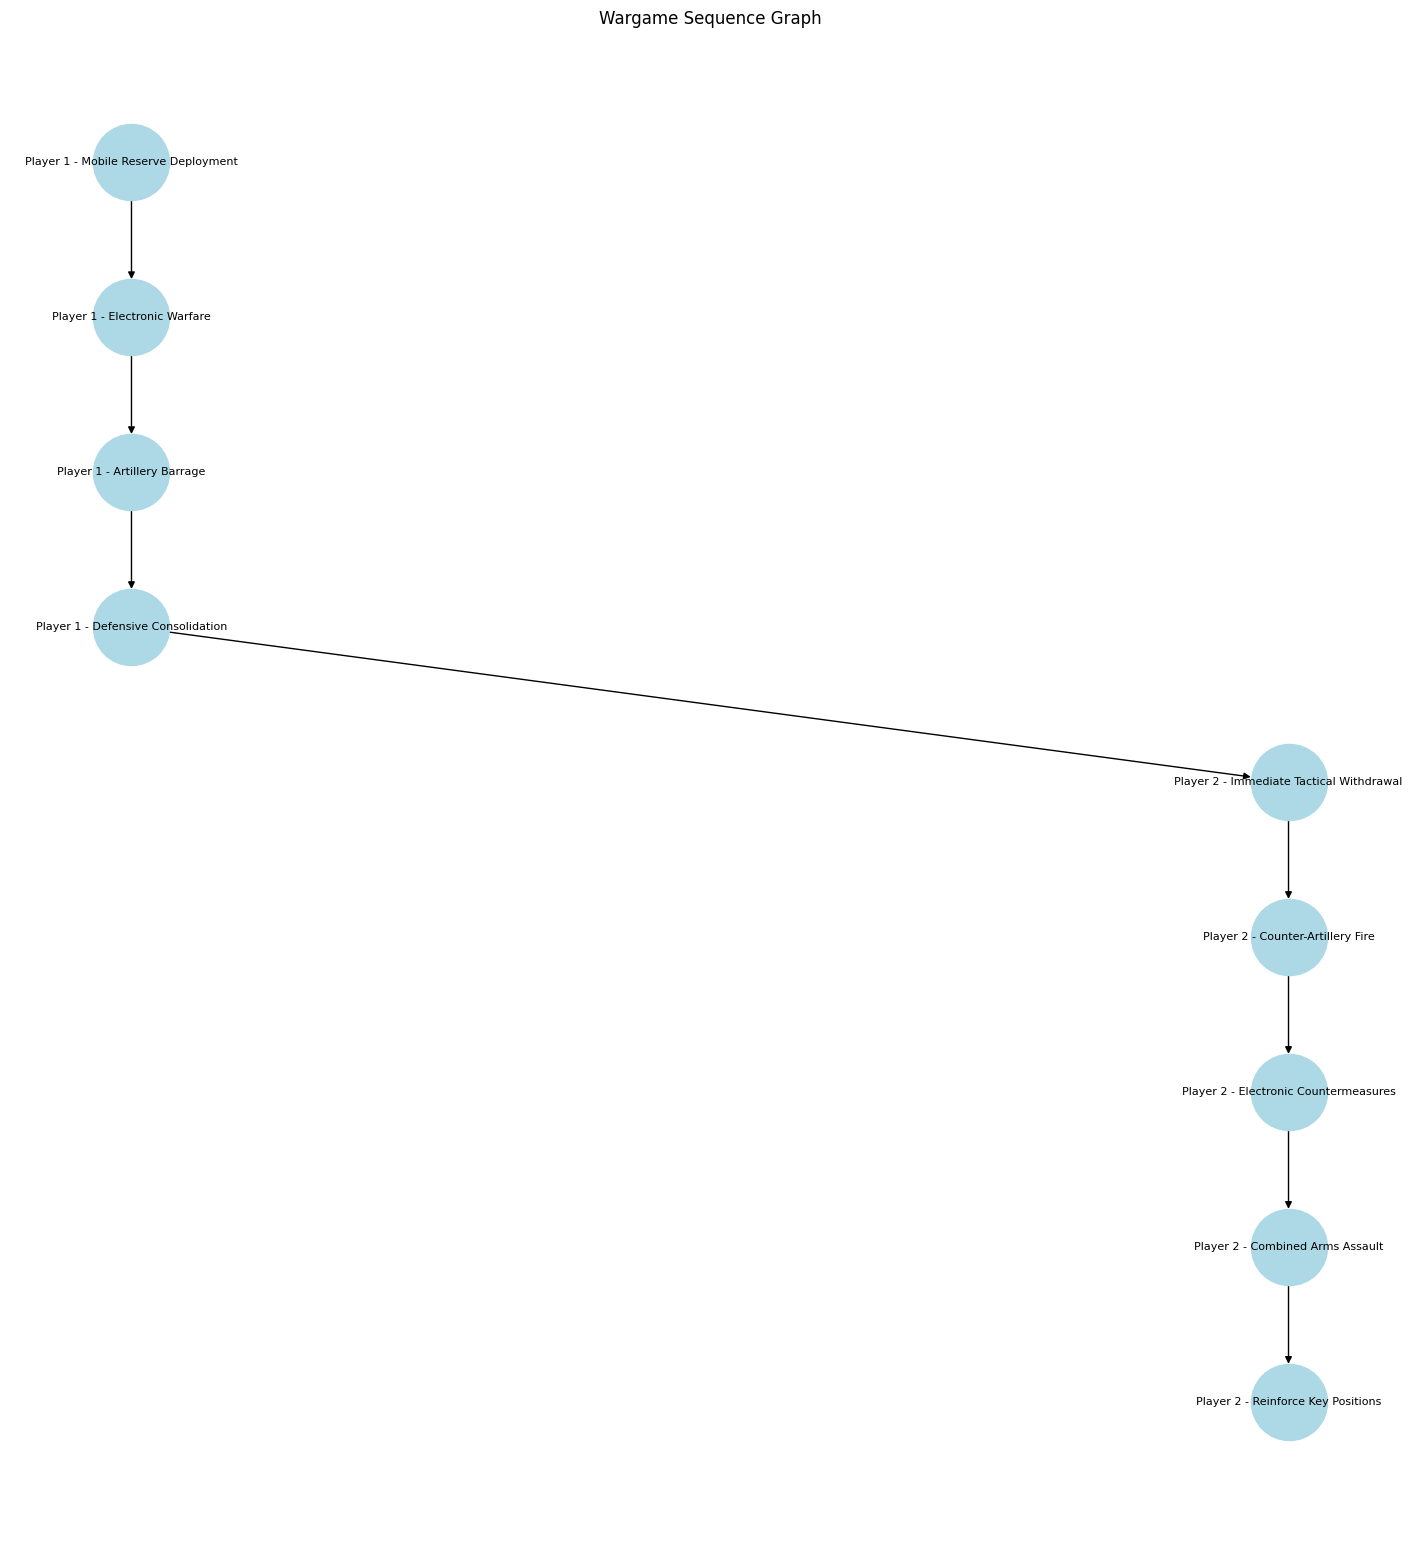

In [119]:
import networkx as nx
import matplotlib.pyplot as plt

# Sample list of node dictionaries (truncated for brevity)
nodes = [
    {'Player': 'Player 1', 'moves': 'Mobile Reserve Deployment', 'turn': 0, 'sim': 0},
    {'Player': 'Player 1', 'moves': 'Electronic Warfare', 'turn': 0, 'sim': 0},
    {'Player': 'Player 1', 'moves': 'Artillery Barrage', 'turn': 0, 'sim': 0},
    {'Player': 'Player 1', 'moves': 'Defensive Consolidation', 'turn': 0, 'sim': 0},
    {'Player': 'Player 2', 'moves': 'Immediate Tactical Withdrawal', 'turn': 1, 'sim': 0},
    {'Player': 'Player 2', 'moves': 'Counter-Artillery Fire', 'turn': 1, 'sim': 0},
    {'Player': 'Player 2', 'moves': 'Electronic Countermeasures', 'turn': 1, 'sim': 0},
    {'Player': 'Player 2', 'moves': 'Combined Arms Assault', 'turn': 1, 'sim': 0},
    {'Player': 'Player 2', 'moves': 'Reinforce Key Positions', 'turn': 1, 'sim': 0},
    # ... continue for all moves
]

# Create a directed graph
G = nx.DiGraph()

# Add nodes
for i, node in enumerate(nodes):
    label = f"{node['Player']} - {node['moves']}"
    G.add_node(i, label=label, turn=node['turn'])

# Add edges by linking each node to the next one in time
for i in range(len(nodes) - 1):
    if nodes[i + 1]['turn'] >= nodes[i]['turn']:  # only forward
        G.add_edge(i, i + 1)

# Position nodes vertically by turn
pos = {}
for i, node in enumerate(nodes):
    pos[i] = (node['turn'], -i)  # turn = x-axis, index = y-axis

# Draw graph
plt.figure(figsize=(14, 15))
labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, labels=labels, with_labels=True, node_color='lightblue', node_size=3000, font_size=8, arrows=True)
plt.title("Wargame Sequence Graph")
plt.axis('off')
plt.show()
